Logistic Accuracy: 1.0
Random Forest Accuracy: 1.0


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Cross Validation: 0.98125


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


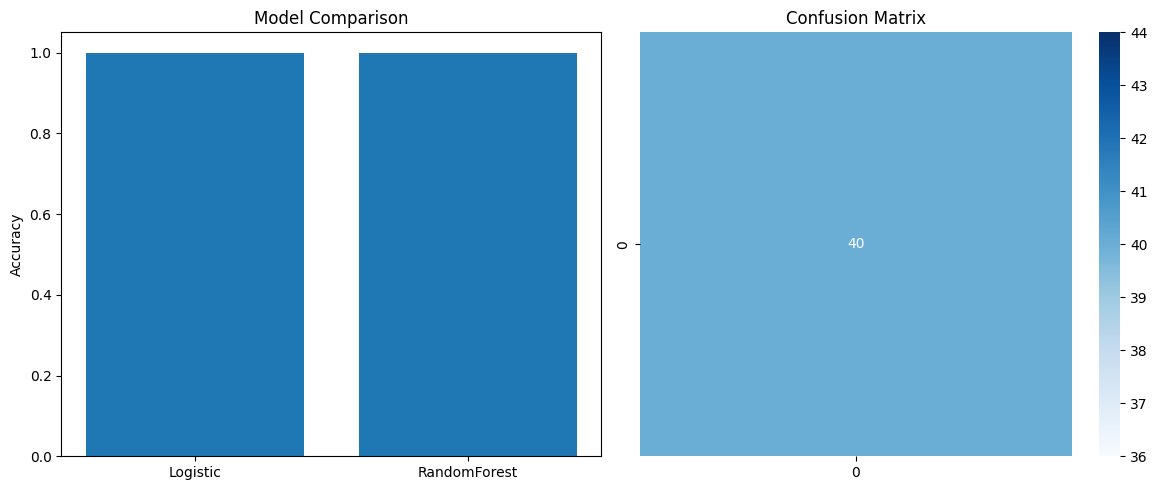

In [2]:
# End-to-End ML Pipeline with Feature Engineering and Model Evaluation
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)

df = pl.DataFrame({
    "StudyHours": np.random.randint(1, 10, 200),
    "SleepHours": np.random.randint(4, 9, 200),
    "Attendance": np.random.randint(50, 100, 200),
    "PreviousMarks": np.random.randint(30, 95, 200)
})

df = df.with_columns([
    (pl.col("StudyHours") + pl.col("Attendance")).alias("Engagement"),
    ((pl.col("StudyHours") * 0.3 +
      pl.col("Attendance") * 0.3 +
      pl.col("PreviousMarks") * 0.4) > 65)
    .cast(pl.Int64)
    .alias("Pass")
])

X = df.select(["StudyHours","SleepHours","Attendance","PreviousMarks","Engagement"]).to_numpy()
y = df.select("Pass").to_numpy().ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model1 = LogisticRegression()
model1.fit(X_train, y_train)

model2 = RandomForestClassifier(n_estimators=100)
model2.fit(X_train, y_train)

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)

acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)

print("Logistic Accuracy:", acc1)
print("Random Forest Accuracy:", acc2)

cv_scores = cross_val_score(model2, X_train, y_train, cv=5)
print("Cross Validation:", cv_scores.mean())

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
models = ["Logistic", "RandomForest"]
accuracies = [acc1, acc2]
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.subplot(1,2,2)
cm = confusion_matrix(y_test, pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()